### Import required Packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

### Download daily Bitcoin price data

In [3]:
btc = yf.download("BTC-USD", start="2016-01-01", end="2026-06-01", progress=False)
btc.to_csv("../data_raw/btc_yfinance.csv")

### Obtain closing prices and Log returns

In [4]:
price = btc["Close"].iloc[:, 0].dropna().rename("price")

returns = (100 *np.log(price / price.shift(1)).dropna().rename("log_return"))

df = pd.concat([price, returns], axis=1).dropna()

print(df.shape[0])

df.head()

3803


,price,log_return
Date,,
2016-01-02,433.437988,-0.206512
2016-01-03,430.010986,-0.793798
2016-01-04,433.091003,0.713712
2016-01-05,431.959991,-0.261490
2016-01-06,429.105011,-0.663130


In [5]:
df.to_csv("../data_clean/btc_daily_returns.csv")

### Some descriptive plots

#### a) Bitcoin price over time

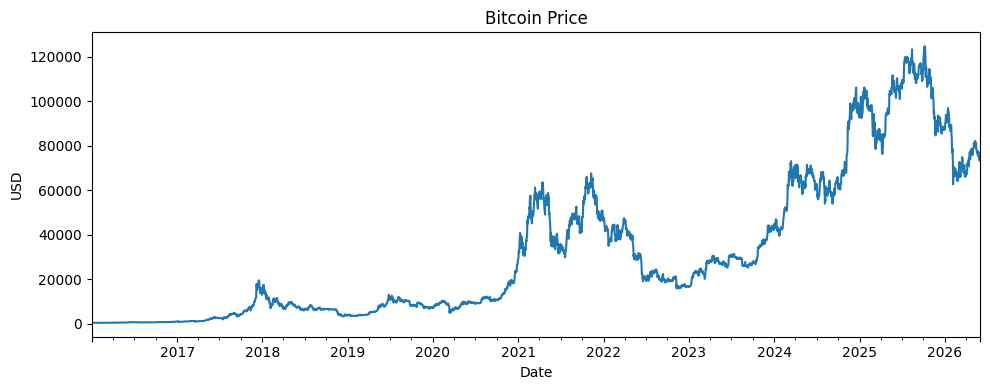

In [6]:
plt.figure(figsize=(10, 4))
df["price"].plot()
plt.title("Bitcoin Price")
plt.ylabel("USD")
plt.tight_layout()
plt.savefig("../output/figures/bitcoin_price.png", dpi=300)
plt.show()

#### b) Daily log returns

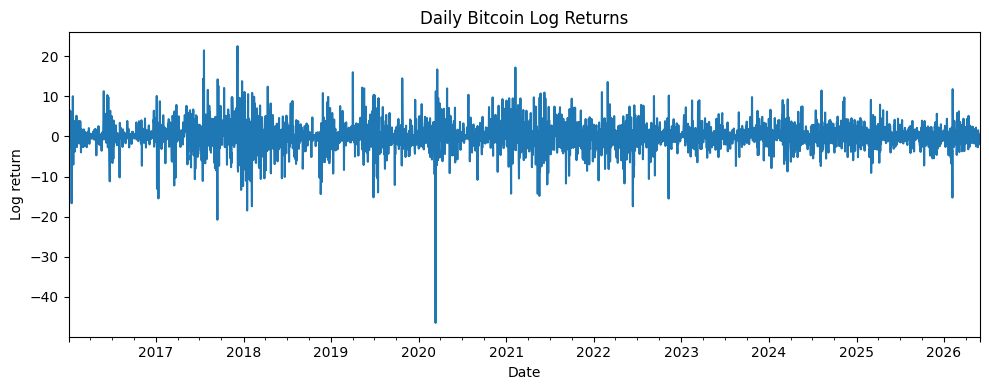

In [7]:
plt.figure(figsize=(10, 4))
df["log_return"].plot()
plt.title("Daily Bitcoin Log Returns")
plt.ylabel("Log return")
plt.tight_layout()
plt.savefig("../output/figures/bitcoin_log_returns.png", dpi=300)
plt.show()

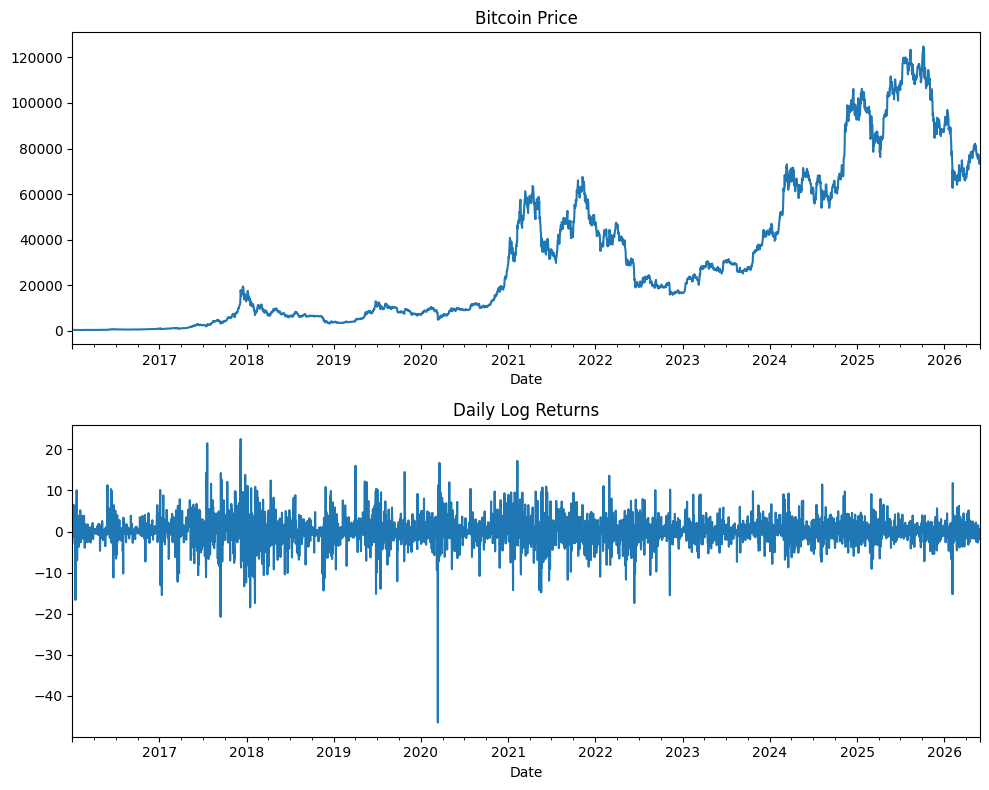

In [8]:
#combine btc price and daily log returns in one figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
df["price"].plot(ax=ax1)
ax1.set_title("Bitcoin Price")
df["log_return"].plot(ax=ax2)
ax2.set_title("Daily Log Returns")
plt.tight_layout()
plt.savefig("../output/figures/bitcoin_price_and_log_returns.png", dpi=300)
plt.show()

#### c) Squared returns as a first view of volatility clustering

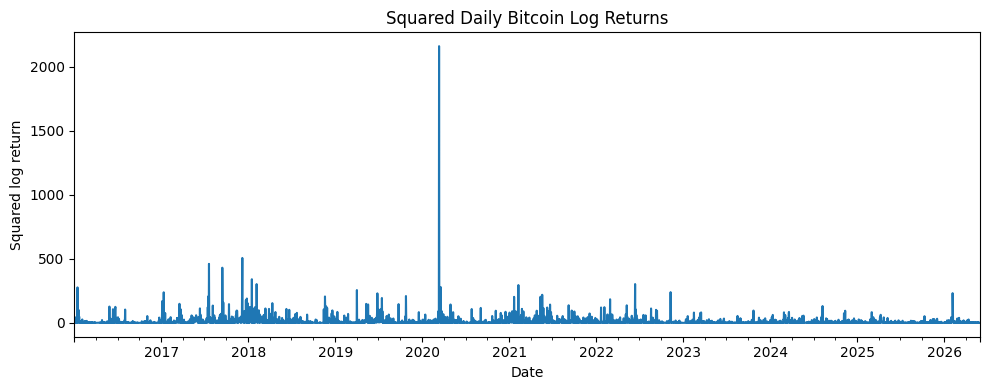

In [9]:
plt.figure(figsize=(10, 4))
(df["log_return"]**2).plot()
plt.title("Squared Daily Bitcoin Log Returns")
plt.ylabel("Squared log return")
plt.tight_layout()
plt.savefig("../output/figures/bitcoin_squared_returns.png", dpi=300)
plt.show()

### Descriptive statistics

In [10]:
r = df["log_return"].dropna().astype(float)

desc_stats = pd.Series({
    "Observations": len(r),
    "Mean": r.mean(),
    "Std. dev.": r.std(ddof=1),
    "Minimum": r.min(),
    "Maximum": r.max(),
    "Skewness": stats.skew(r, bias=False),
    "Kurtosis": stats.kurtosis(r, fisher=False, bias=False),  # normal = 3
    "Excess kurtosis": stats.kurtosis(r, fisher=True, bias=False),  # normal = 0
})

jb_result = stats.jarque_bera(r)

jb_stats = pd.Series({
    "Jarque-Bera statistic": jb_result.statistic,
    "JB p-value": jb_result.pvalue,
})

summary_table = pd.concat([desc_stats, jb_stats]).to_frame(name="Value")

summary_table

,Value
Observations,3803.000000
Mean,0.134954
Std. dev.,3.502875
Minimum,-46.473018
Maximum,22.511895
Skewness,-0.663635
Kurtosis,15.323938
Excess kurtosis,12.323938
Jarque-Bera statistic,24276.121795
JB p-value,0.000000


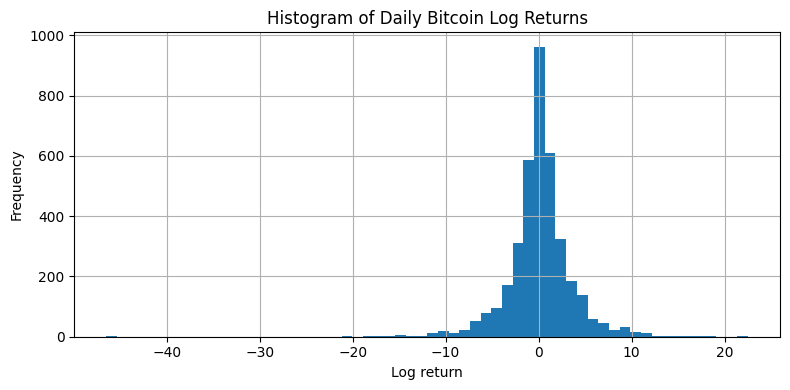

In [11]:
plt.figure(figsize=(8, 4))
df["log_return"].hist(bins=60)
plt.title("Histogram of Daily Bitcoin Log Returns")
plt.xlabel("Log return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../output/figures/bitcoin_return_histogram.png", dpi=300)
plt.show()

#### ADF Test

In [12]:
adf_result = adfuller(df["log_return"])

print("ADF statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Used lag:", adf_result[2])
print("Number of observations:", adf_result[3])
print("Critical values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value:.4f}")

ADF statistic: -42.943102153041146
p-value: 0.0
Used lag: 1
Number of observations: 3801
Critical values:
  1%: -3.4321
  5%: -2.8623
  10%: -2.5672


In [13]:
for lag in [0, 1, 2, 5, 10, 20, 30]:
    result = adfuller(df["log_return"], maxlag=lag, regression="c", autolag=None)

    print(f"\nFixed lag: {lag}")
    print(f"ADF statistic: {result[0]:.6f}")
    print(f"p-value: {result[1]:.6g}")


Fixed lag: 0
ADF statistic: -63.575106
p-value: 0

Fixed lag: 1
ADF statistic: -42.943102
p-value: 0

Fixed lag: 2
ADF statistic: -35.156065
p-value: 0

Fixed lag: 5
ADF statistic: -23.821526
p-value: 0

Fixed lag: 10
ADF statistic: -17.640086
p-value: 3.76254e-30

Fixed lag: 20
ADF statistic: -12.397411
p-value: 4.64179e-23

Fixed lag: 30
ADF statistic: -10.264769
p-value: 4.14684e-18


#### ACF of returns

<Figure size 800x400 with 0 Axes>

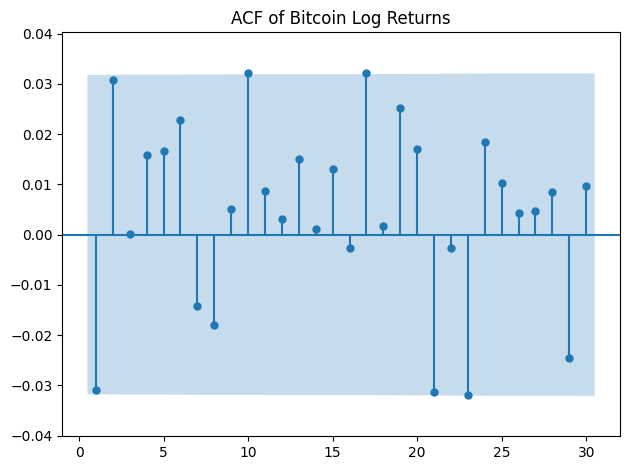

In [24]:
plt.figure(figsize=(8, 4))
plot_acf(df["log_return"], lags=30, zero=False, alpha=0.05, auto_ylims=True)
plt.title("ACF of Bitcoin Log Returns")
plt.tight_layout()
plt.savefig("../output/figures/ACF_of_bitcoin_log_returns.png", dpi=300)
plt.show()

#### Ljung-Box test on returns

In [15]:
lb_returns = acorr_ljungbox(df["log_return"], lags=[10, 20, 30], return_df=True)
print("Ljung-Box test on returns:")
print(lb_returns)

Ljung-Box test on returns:
      lb_stat  lb_pvalue
10  17.261794   0.068768
20  26.634752   0.145856
30  39.116059   0.123150


#### ACF of squared returns

<Figure size 800x400 with 0 Axes>

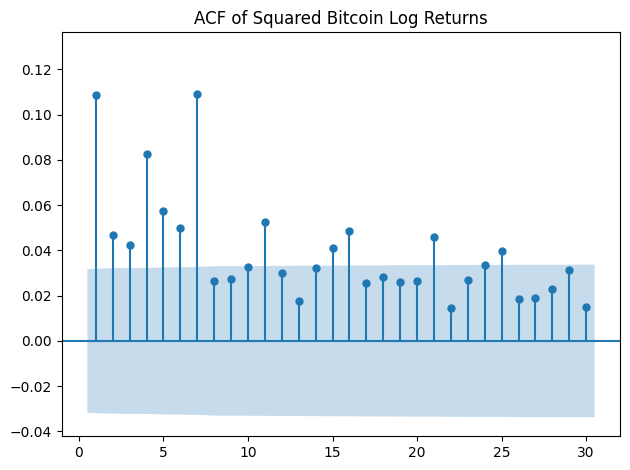

In [25]:
plt.figure(figsize=(8, 4))
plot_acf(df["log_return"]**2, lags=30, zero=False, alpha=0.05, auto_ylims=True)
plt.title("ACF of Squared Bitcoin Log Returns")
plt.tight_layout()
plt.savefig("../output/figures/ACF_of_squared_bitcoin_log_returns.png", dpi=300)
plt.show()

#### Ljung-Box test on squared returns

In [17]:
lb_sq_returns = acorr_ljungbox(df["log_return"]**2, lags=[10, 20, 30], return_df=True)
print("Ljung-Box test on squared returns:")
print(lb_sq_returns)

Ljung-Box test on squared returns:
       lb_stat     lb_pvalue
10  163.270193  6.841678e-30
20  208.888584  1.946862e-33
30  240.193911  1.171912e-34


#### ARCH-LM test

In [18]:
arch_test = het_arch(df["log_return"], nlags=10)

print("ARCH-LM statistic:", arch_test[0])
print("ARCH-LM p-value:", arch_test[1])
print("F-statistic:", arch_test[2])
print("F-test p-value:", arch_test[3])

ARCH-LM statistic: 118.95249074796874
ARCH-LM p-value: 8.253738946700047e-21
F-statistic: 12.244760550208714
F-test p-value: 3.762087658067479e-21
